YOLOv8m + ECA+CBAM

Environment

In [1]:
# Detects whether the notebook is running on Kaggle, Colab, or local Jupyter and sets ROOT and OUTPUT_DIR accordingly.
import os, sys

ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
if ON_KAGGLE:
    ROOT = "/kaggle/working"
elif ON_COLAB:
    ROOT = "/content"
else:
    ROOT = "."
print("Running on:", "KAGGLE" if ON_KAGGLE else "COLAB" if ON_COLAB else "LOCAL")
OUTPUT_DIR = os.path.join(ROOT, "attention_results")
SAVE_DIR = os.path.join(ROOT, "saved_models")
for d in [OUTPUT_DIR, SAVE_DIR]:
    os.makedirs(d, exist_ok=True)
print(f"Output : {OUTPUT_DIR}")
print(f"Models : {SAVE_DIR}")


Running on: LOCAL
Output : ./attention_results
Models : ./saved_models


In [2]:
# Installs kagglehub, matplotlib, pillow and numpy.
!pip install kagglehub matplotlib pillow numpy -q

Verify Environment

In [3]:
# Prints package versions and confirms GPU availability, device name and VRAM.
import torch, numpy as np, pandas as pd, cv2, random, gc

print(f"PyTorch : {torch.__version__}")
print(f"OpenCV  : {cv2.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device  : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
try:
    import ultralytics, seaborn, tqdm, kagglehub, yaml

    print("All packages OK")
except ImportError as e:
    print(f"Missing: {e}")
    print("Run: pip install ultralytics seaborn tqdm kagglehub pyyaml")


PyTorch : 2.10.0+cu128
OpenCV  : 4.13.0
Device  : cuda
GPU     : NVIDIA GeForce RTX 3090
VRAM    : 25.4 GB
All packages OK


Config

In [4]:
# Defines the training and evaluation config: two-phase epochs and learning rates, batch size, image size, weight decay, worker count, seeds, CBAM hyperparameters, and the confidence sweep grid.
EPOCHS_FROZEN = 10
EPOCHS_FULL = 40
BATCH = 16
IMG_SIZE = 640
LR_FROZEN = 1e-3
LR_FULL = 2e-4
WEIGHT_DECAY = 5e-4


NUM_WORKERS = 2

# Multi-seed
SEEDS = [42, 123, 456]

# Attention
CBAM_REDUCTION = 16
CBAM_KERNEL = 7

# Evaluation
CONF_SWEEP = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]
CONF_DEFAULT = 0.25
IOU_THRESH = 0.5

 Dataset + MD5 Deduplication

In [5]:
# Downloads the three Kaggle datasets, loads every annotation through the unified loader, and removes duplicates by MD5 hash before any split.
import kagglehub, shutil, yaml
from pathlib import Path
import xml.etree.ElementTree as ET

print("Downloading datasets ...")
path_1 = kagglehub.dataset_download("chitholian/annotated-potholes-dataset")
path_2 = kagglehub.dataset_download("andrewmvd/pothole-detection")
path_3 = kagglehub.dataset_download("ashishkumarak/training-setzip")
DATASET_ROOTS = {"chitholian": path_1, "andrewmvd": path_2, "ashishkumar": path_3}
print("Datasets ready")


def load_annotated_potholes(root):
    root = Path(root)
    records = []
    for img_path in list(root.rglob("*.jpg")) + list(root.rglob("*.png")):
        xml_path = img_path.with_suffix(".xml")
        if not xml_path.exists():
            xml_path = img_path.parent.parent / "annotations" / (img_path.stem + ".xml")
        gt_boxes = []
        if xml_path.exists():
            try:
                tree = ET.parse(xml_path)
                for obj in tree.findall("object"):
                    bb = obj.find("bndbox")
                    gt_boxes.append(
                        [
                            float(bb.find("xmin").text),
                            float(bb.find("ymin").text),
                            float(bb.find("xmax").text),
                            float(bb.find("ymax").text),
                        ]
                    )
            except Exception:
                pass
        records.append({"image_path": img_path, "gt_boxes": gt_boxes})
    return records


import pandas as pd


def load_ashishkumar_csv(root):
    root = Path(root)
    df = pd.read_csv(root / "train" / "labels.csv")
    grouped = df.groupby("ImageID")
    records = []
    for img_path in sorted((root / "train" / "images").glob("*.jpg")):
        gt_boxes = []
        if img_path.name in grouped.groups:
            for _, row in grouped.get_group(img_path.name).iterrows():
                gt_boxes.append(
                    [
                        float(row["XMin"]),
                        float(row["YMin"]),
                        float(row["XMax"]),
                        float(row["YMax"]),
                    ]
                )
        records.append({"image_path": img_path, "gt_boxes": gt_boxes})
    return records


all_records = []
for name, root in DATASET_ROOTS.items():
    recs = (
        load_ashishkumar_csv(root)
        if name == "ashishkumar"
        else load_annotated_potholes(root)
    )
    print(
        f"  {name}: {len(recs)} images ({sum(len(r['gt_boxes']) for r in recs)} gt boxes)"
    )
    all_records.extend(recs)

print(f"Before dedup: {len(all_records)}")


import numpy as np
from PIL import Image

NORM_SIZE = (64, 64)
DEDUP_THRESHOLD = 1.0


def normalized_pixels(path):
    with Image.open(path) as img:
        return np.asarray(
            img.convert("L").resize(NORM_SIZE, Image.LANCZOS), dtype=np.float32
        ).ravel()


annotated_only = [r for r in all_records if r["gt_boxes"]]
print("Computing normalized pixel arrays for dedup ...")
all_arrs = np.stack([normalized_pixels(r["image_path"]) for r in annotated_only])

keep_mask = np.ones(len(annotated_only), dtype=bool)
seen_arrs = []
for i in range(len(annotated_only)):
    if not keep_mask[i]:
        continue
    if seen_arrs:
        diffs = np.abs(np.stack(seen_arrs) - all_arrs[i]).mean(axis=1)
        if diffs.min() < DEDUP_THRESHOLD:
            keep_mask[i] = False
            continue
    seen_arrs.append(all_arrs[i])

records = [r for r, keep in zip(annotated_only, keep_mask) if keep]
print(f"After dedup: {len(records)}")
print(f"Duplicates removed: {len(all_records) - len(records)}")


Datasets ready
  chitholian: 665 images (1740 gt boxes)
  andrewmvd: 665 images (1740 gt boxes)
  ashishkumar: 674 images (1371 gt boxes)
Before dedup: 2004
Computing normalized pixel arrays for dedup ...
After dedup: 926
Duplicates removed: 1078


Build YOLO Dataset (fixed split, seed=42)

In [6]:
# Shuffles the deduplicated records under seed 42, splits 80/20, and writes the YOLO-format image and label directories plus data.yaml.
random.seed(42)
np.random.seed(42)
random.shuffle(records)
split_idx = int(len(records) * 0.8)
train_recs, val_recs = records[:split_idx], records[split_idx:]
print(f"Train: {len(train_recs)}  Val: {len(val_recs)}")

YOLO_DIR = os.path.join(ROOT, "yolo_dataset")
DATA_YAML = f"{YOLO_DIR}/data.yaml"
for split in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(f"{YOLO_DIR}/{split}", exist_ok=True)


def convert_to_yolo(rec_list, split):
    written = 0
    for rec in rec_list:
        img = cv2.imread(str(rec["image_path"]))
        if img is None:
            continue
        h, w = img.shape[:2]
        dst = f"{YOLO_DIR}/images/{split}/{rec['image_path'].name}"
        if not os.path.exists(dst):
            shutil.copy(str(rec["image_path"]), dst)
        with open(f"{YOLO_DIR}/labels/{split}/{rec['image_path'].stem}.txt", "w") as f:
            for box in rec["gt_boxes"]:
                x1, y1, x2, y2 = box
                f.write(
                    f"0 {((x1 + x2) / 2) / w:.6f} {((y1 + y2) / 2) / h:.6f} "
                    f"{(x2 - x1) / w:.6f} {(y2 - y1) / h:.6f}\n"
                )
        written += 1
    return written


n_tr = convert_to_yolo(train_recs, "train")
n_va = convert_to_yolo(val_recs, "val")
with open(DATA_YAML, "w") as f:
    yaml.dump(
        {
            "path": YOLO_DIR,
            "train": "images/train",
            "val": "images/val",
            "nc": 1,
            "names": ["pothole"],
        },
        f,
    )
print(f"YOLO dataset: train={n_tr}  val={n_va}")


Train: 740  Val: 186
YOLO dataset: train=740  val=186


 Attention Modules

In [7]:
# Defines ECA, the CBAM channel and spatial sub-modules, and the three attention variants ECA_Only, CBAM_Only and ECA_CBAM, each wrapped in a zero-initialized learnable residual gate.
import torch, torch.nn as nn, math


class ECA(nn.Module):
    def __init__(self, in_channels, gamma=2, b=1):
        super().__init__()
        t = int(abs(math.log2(in_channels) / gamma) + b / gamma)
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=(k - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x).squeeze(-1).transpose(-1, -2)
        y = self.sigmoid(self.conv(y)).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, 1, keepdim=True)
        mx, _ = torch.max(x, 1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], 1)))


class ECA_Only(nn.Module):
    "Ablation B -- channel only."

    def __init__(self, in_channels):
        super().__init__()
        self.eca = ECA(in_channels)
        self.scale = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return x + torch.tanh(self.scale) * (self.eca(x) - x)


class CBAM_Only(nn.Module):
    "Ablation C -- spatial+channel, no ECA pre-stage."

    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(kernel_size)
        self.scale = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        att = x * self.ca(x)
        att = att * self.sa(att)
        return x + torch.tanh(self.scale) * (att - x)


class ECA_CBAM(nn.Module):
    "Main model -- ECA then CBAM, residual scale init at 0."

    def __init__(self, in_channels, cbam_reduction=16, cbam_kernel=7):
        super().__init__()
        self.eca = ECA(in_channels)
        self.ca = ChannelAttention(in_channels, cbam_reduction)
        self.sa = SpatialAttention(cbam_kernel)
        self.scale = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        att = self.eca(x)
        att = att * self.ca(att)
        att = att * self.sa(att)
        return x + torch.tanh(self.scale) * (att - x)


dummy = torch.randn(2, 256, 20, 20)
for cls in [ECA_Only, CBAM_Only, ECA_CBAM]:
    m = cls(256)
    out = m(dummy)
    n_p = sum(p.numel() for p in m.parameters())
    diff = (out - dummy).abs().max().item()
    print(f"{cls.__name__:<12}: params={n_p:,}  init_diff={diff:.6f} (should be 0)")


ECA_Only    : params=6  init_diff=0.000000 (should be 0)
CBAM_Only   : params=8,291  init_diff=0.000000 (should be 0)
ECA_CBAM    : params=8,296  init_diff=0.000000 (should be 0)


 Hook Injector

In [8]:
# Defines get_neck_modules and AttentionHookInjector, which locate the neck layers and attach the attention modules as forward hooks.
def get_neck_modules(yolo_detection_model):
    if hasattr(yolo_detection_model, "model") and isinstance(
        yolo_detection_model.model, nn.Sequential
    ):
        layer_seq = yolo_detection_model.model
    else:
        children = list(yolo_detection_model.children())
        layer_seq = next((c for c in children if isinstance(c, nn.Sequential)), None)
        if layer_seq is None:
            raise RuntimeError("Cannot locate Sequential inside DetectionModel")
    NECK_NAMES = {"C3k2", "C2f", "C2fAttn", "RepC3", "C3"}
    candidates = [
        (i, l, type(l).__name__)
        for i, l in enumerate(list(layer_seq))
        if type(l).__name__ in NECK_NAMES
    ]
    print(f"  Total layers: {len(list(layer_seq))}  neck candidates: {len(candidates)}")
    if not candidates:
        raise RuntimeError(
            f"No neck layers. Classes: {set(type(l).__name__ for l in list(layer_seq))}"
        )
    return [
        l for (_, l, _) in (candidates[-3:] if len(candidates) >= 3 else candidates)
    ]


class AttentionHookInjector:
    def __init__(
        self, yolo_detection_model, attention_cls, cbam_reduction=16, cbam_kernel=7
    ):
        self._hooks = []
        self.attention_modules = nn.ModuleList()
        self._device = next(yolo_detection_model.parameters()).device

        neck_layers = get_neck_modules(yolo_detection_model)
        real_channels = [None] * len(neck_layers)
        probe_hooks = []

        def make_probe(i):
            def hook(module, inp, out):
                t = out[0] if isinstance(out, (list, tuple)) else out
                real_channels[i] = t.shape[1]

            return hook

        for i, layer in enumerate(neck_layers):
            probe_hooks.append(layer.register_forward_hook(make_probe(i)))
        try:
            dummy = torch.zeros(1, 3, 640, 640, device=self._device)
            with torch.no_grad():
                yolo_detection_model(dummy)
        except Exception as e:
            print(f"  Probe note: {e}")
        finally:
            for h in probe_hooks:
                h.remove()

        for i, (layer, c) in enumerate(zip(neck_layers, real_channels)):
            if c is None:
                print(f"  Layer {i}: probe failed")
                continue
            if attention_cls == ECA_Only:
                att = ECA_Only(c).to(self._device)
            elif attention_cls == CBAM_Only:
                att = CBAM_Only(c, cbam_reduction, cbam_kernel).to(self._device)
            else:
                att = ECA_CBAM(c, cbam_reduction, cbam_kernel).to(self._device)
            self.attention_modules.append(att)
            n_p = sum(p.numel() for p in att.parameters())
            print(f"  Neck layer {i}: ch={c}  {attention_cls.__name__}  params={n_p:,}")
        self._neck_layers = neck_layers

    def attach(self):
        self._hooks = []
        for layer, att in zip(self._neck_layers, self.attention_modules):

            def make_hook(a):
                def hook(module, inp, out):
                    if isinstance(out, (list, tuple)):
                        return type(out)([a(out[0])] + list(out[1:]))
                    return a(out)

                return hook

            self._hooks.append(layer.register_forward_hook(make_hook(att)))
        print(f"  {len(self._hooks)} hooks attached")

    def detach(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []
        print("  Hooks removed")

    def n_params(self):
        return sum(p.numel() for p in self.attention_modules.parameters())

    def state_dict(self):
        return self.attention_modules.state_dict()


print("AttentionHookInjector defined")


AttentionHookInjector defined


 Evaluation Helper

In [9]:
# Defines evaluate_with_val, which scores a model through Ultralytics model.val() for COCO-style mAP@0.5 and mAP@0.5:0.95.
from tqdm import tqdm
import time


def evaluate_with_val(yolo_model, data_yaml, conf=0.25, iou=0.5):
    "Proper COCO-style mAP@0.5 and mAP@0.5:0.95 via model.val()."
    res = yolo_model.val(
        data=data_yaml,
        conf=conf,
        iou=iou,
        verbose=False,
        plots=False,
        workers=NUM_WORKERS,
    )
    mp = float(res.box.mp)
    mr = float(res.box.mr)
    f1 = 2 * mp * mr / (mp + mr) if (mp + mr) > 0 else 0.0
    return {
        "mAP@0.5": round(float(res.box.map50), 4),
        "mAP@0.5:0.95": round(float(res.box.map), 4),
        "Precision": round(mp, 4),
        "Recall": round(mr, 4),
        "F1": round(f1, 4),
        "conf": conf,
    }


def run_conf_sweep(yolo_model, data_yaml, conf_sweep, iou=0.5):
    rows = []
    for conf in tqdm(conf_sweep, desc="conf sweep"):
        rows.append(evaluate_with_val(yolo_model, data_yaml, conf=conf, iou=iou))
    df = pd.DataFrame(rows).set_index("conf")
    best_conf = df["F1"].idxmax()
    return df, best_conf


print("evaluate_with_val + run_conf_sweep defined")


evaluate_with_val + run_conf_sweep defined


Two-Phase Training Function

In [10]:
# Defines set_seed and two_phase_train, 10 frozen-backbone epochs followed by 40 full fine-tuning epochs
import time, pathlib, shutil, json as _json
from ultralytics import YOLO


def set_seed(seed):
    import random, numpy as np

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def two_phase_train(
    run_name,
    attention_cls,
    seed=42,
    base_weights="yolov8m.pt",
    cbam_reduction=16,
    cbam_kernel=7,
):

    set_seed(seed)
    print(f"\\n{'=' * 62}")
    attn_name = attention_cls.__name__ if attention_cls else "Baseline"
    print(f"  {run_name}  |  {attn_name}  |  seed={seed}")
    print(f"{'=' * 62}")

    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    live_injector = {"obj": None}

    def _attach_on_train_start(trainer):
        """Fires after Ultralytics has built/loaded trainer.model --
        this IS the object that will actually be optimized."""
        if attention_cls is None:
            return
        inj = AttentionHookInjector(
            trainer.model, attention_cls, cbam_reduction, cbam_kernel
        )
        inj.attach()
        live_injector["obj"] = inj

        if hasattr(trainer, "optimizer") and trainer.optimizer is not None:
            last_group = (
                trainer.optimizer.param_groups[-1]
                if trainer.optimizer.param_groups
                else {}
            )
            new_group = {"params": list(inj.attention_modules.parameters())}
            new_group["lr"] = last_group.get("lr", LR_FROZEN)
            new_group["initial_lr"] = last_group.get("initial_lr", new_group["lr"])
            trainer.optimizer.add_param_group(new_group)

            sched = getattr(trainer, "scheduler", None)
            if sched is not None:
                n_groups = len(trainer.optimizer.param_groups)
                if hasattr(sched, "base_lrs") and len(sched.base_lrs) < n_groups:
                    sched.base_lrs.append(sched.base_lrs[-1])
                if hasattr(sched, "lr_lambdas") and len(sched.lr_lambdas) < n_groups:
                    sched.lr_lambdas.append(sched.lr_lambdas[-1])

            print(
                f"  [callback] {sum(p.numel() for p in inj.attention_modules.parameters()):,} "
                f"attention params registered with optimizer"
            )
        else:
            print(
                "  [callback] WARNING: trainer.optimizer not found yet -- "
                "attention params will NOT be trained this phase"
            )

        total_params = sum(p.numel() for p in trainer.model.parameters())
        print(
            f"  [callback] hooks attached to live trainer.model  "
            f"Overhead: {inj.n_params() / total_params * 100:.2f}%  "
            f"({inj.n_params():,} params)"
        )

    def _detach_on_train_end(trainer):
        inj = live_injector.get("obj")
        if inj is not None:
            inj.detach()

    # Phase 1
    model_obj = YOLO(base_weights)
    model_obj.to(DEVICE)

    model_obj.add_callback("on_train_start", _attach_on_train_start)
    model_obj.add_callback("on_train_end", _detach_on_train_end)

    print(f"Phase 1: {EPOCHS_FROZEN} epochs, freeze backbone, LR={LR_FROZEN}")
    t0 = time.time()
    model_obj.train(
        data=DATA_YAML,
        epochs=EPOCHS_FROZEN,
        imgsz=IMG_SIZE,
        batch=BATCH,
        lr0=LR_FROZEN,
        lrf=0.1,
        weight_decay=WEIGHT_DECAY,
        freeze=10,
        device=DEVICE,
        name=f"{run_name}_p1",
        exist_ok=True,
        verbose=True,
        plots=False,
        save=True,
        seed=seed,
        workers=NUM_WORKERS,  # FIX: workers capped
    )
    print(f"Phase 1 done in {(time.time() - t0) / 60:.1f} min")

    model_obj.to(DEVICE)

    runs_dir = pathlib.Path("runs/detect")
    p1_best = runs_dir / f"{run_name}_p1" / "weights" / "best.pt"
    p1_last = runs_dir / f"{run_name}_p1" / "weights" / "last.pt"
    p1_weights = str(p1_best) if p1_best.exists() else str(p1_last)

    del model_obj
    live_injector["obj"] = None
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # Phase 2
    model_obj = YOLO(p1_weights)
    model_obj.to(DEVICE)
    set_seed(seed)

    model_obj.add_callback("on_train_start", _attach_on_train_start)
    model_obj.add_callback("on_train_end", _detach_on_train_end)

    print(f"Phase 2: {EPOCHS_FULL} epochs, all layers, LR={LR_FULL}")
    t0 = time.time()
    model_obj.train(
        data=DATA_YAML,
        epochs=EPOCHS_FULL,
        imgsz=IMG_SIZE,
        batch=BATCH,
        lr0=LR_FULL,
        lrf=0.01,
        weight_decay=WEIGHT_DECAY,
        freeze=0,
        device=DEVICE,
        name=f"{run_name}_p2",
        exist_ok=True,
        verbose=True,
        plots=False,
        save=True,
        seed=seed,
        workers=NUM_WORKERS,  # FIX: workers capped
    )
    print(f"Phase 2 done in {(time.time() - t0) / 60:.1f} min")

    model_obj.to(DEVICE)

    p2_best = runs_dir / f"{run_name}_p2" / "weights" / "best.pt"
    p2_last = runs_dir / f"{run_name}_p2" / "weights" / "last.pt"
    p2_weights = str(p2_best) if p2_best.exists() else str(p2_last)

    eval_injector = None
    if attention_cls is not None:
        eval_injector = AttentionHookInjector(
            model_obj.model, attention_cls, cbam_reduction, cbam_kernel
        )
        trained_obj = live_injector.get("obj")
        if trained_obj is not None:
            eval_injector.attention_modules.load_state_dict(
                trained_obj.attention_modules.state_dict()
            )
        else:
            print(
                "  WARNING: no trained attention weights found -- "
                "evaluating with untrained (zero-init) attention"
            )
        eval_injector.attach()

    print("Evaluating ...")
    metrics_default = evaluate_with_val(
        model_obj, DATA_YAML, conf=CONF_DEFAULT, iou=IOU_THRESH
    )
    _, best_conf = run_conf_sweep(model_obj, DATA_YAML, CONF_SWEEP, iou=IOU_THRESH)
    metrics_best = evaluate_with_val(
        model_obj, DATA_YAML, conf=float(best_conf), iou=IOU_THRESH
    )

    attention_sd = eval_injector.state_dict() if eval_injector else None
    if eval_injector is not None:
        eval_injector.detach()

    if attention_sd is not None:
        ckpt_path = os.path.join(SAVE_DIR, f"{run_name}_complete.pt")
        torch.save(
            {
                "yolo_weights_path": p2_weights,
                "attention_state_dict": attention_sd,
                "neck_channels": [192, 384, 576],
                "attention_cls": attention_cls.__name__,
                "cbam_reduction": cbam_reduction,
                "cbam_kernel": cbam_kernel,
                "seed": seed,
                "metrics_default": metrics_default,
                "metrics_best": metrics_best,
            },
            ckpt_path,
        )
        print(f"Complete checkpoint: {ckpt_path}")
    shutil.copy(p2_weights, os.path.join(SAVE_DIR, f"{run_name}_yolo.pt"))

    result_json = os.path.join(OUTPUT_DIR, f"{run_name}_result.json")
    with open(result_json, "w") as f:
        _json.dump(
            {
                "run_name": run_name,
                "seed": seed,
                "attention": attention_cls.__name__ if attention_cls else "None",
                "p2_weights": p2_weights,
                "metrics_default": metrics_default,
                "metrics_best": metrics_best,
                "best_conf": float(best_conf),
            },
            f,
            indent=2,
        )
    print(f"Result JSON: {result_json}")

    del model_obj
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return p2_weights, attention_sd, metrics_default, metrics_best, float(best_conf)


print(
    "two_phase_train defined"
)


two_phase_train defined


In [11]:
# Smoke test: trains the baseline and CBAM-only variants for one epoch each to confirm the hooks reach the live trainer and the attention scales are actually updated, then restores the full epoch counts.
_orig_frozen, _orig_full = EPOCHS_FROZEN, EPOCHS_FULL
EPOCHS_FROZEN, EPOCHS_FULL = 1, 1

smoke_results = []
for run_name, att_cls, label in [
    ("smoke_Baseline", None, "Baseline"),
    ("smoke_CBAM_Only", CBAM_Only, "CBAM_Only"),
]:
    _, att_sd, m_def, _, _ = two_phase_train(
        run_name=run_name, attention_cls=att_cls, seed=42, base_weights="yolov8m.pt"
    )
    smoke_results.append({"label": label, **m_def})
    if att_sd is not None:
        print(f"  {label} scale values:")
        for k, v in att_sd.items():
            if "scale" in k:
                print(f"    {k}: raw={v.item():+.6f}  tanh={torch.tanh(v).item():+.6f}")

print()
print(
    pd.DataFrame(smoke_results)[
        ["label", "mAP@0.5", "Precision", "Recall", "F1"]
    ].to_string(index=False)
)
print()
print(
    "Check: (1) mAP@0.5 should differ between rows. "
    "(2) scale values above should be non-zero."
)

EPOCHS_FROZEN, EPOCHS_FULL = _orig_frozen, _orig_full


\n==============================================================
  smoke_Baseline  |  Baseline  |  seed=42
Phase 1: 1 epochs, freeze backbone, LR=0.001
New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.10.9 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24252MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=No

conf sweep:   0%|                                                                              | 0/13 [00:00<?, ?it/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6362.8±2916.1 MB/s, size: 87.2 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 60.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.9it/s 1.0s0.1s
                   all        186        474       0.42      0.407      0.325      0.136
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 0.2ms postprocess per image


conf sweep:   8%|█████▍                                                                | 1/13 [00:01<00:13,  1.16s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7472.1±2857.0 MB/s, size: 130.5 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 60.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 12.0it/s 1.0s0.1s
                   all        186        474       0.42      0.407      0.332      0.142
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 0.2ms postprocess per image


...

conf sweep:  92%|███████████████████████████████████████████████████████████████▋     | 12/13 [00:14<00:01,  1.20s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3661.1±485.7 MB/s, size: 201.6 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 65.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.5it/s 1.0s.1s
                   all        186        474      0.692      0.209      0.421      0.227
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 0.1ms postprocess per image


conf sweep: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [00:15<00:00,  1.21s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3998.0±2920.2 MB/s, size: 74.4 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 70.9Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.3it/s 1.1s.1s
                   all        186        474       0.43      0.426      0.395      0.191
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 0.2ms postprocess per image
  Hooks removed
Complete checkpoint: ./saved_models/smoke_CBAM_Only_complete.pt
Result JSON: ./attention_results/smoke_CBAM_Only_result.json
  CBAM_Only scale values:
    0.scale: raw=-0.000283  tanh=-0.000283
    1.scale: raw=+0.000956  tanh=+0.000956
    2.scale: raw=+0.000901  tanh=+0.000901

    label  mAP@0.5  Precision  Recall     F1
 Baseline   0.3488     0.4200  0.4072 0.4135
CBAM_Only   0.3926     0.5018  0.3569 0.4171

Check: (1) mAP@0.5 should differ between rows. (2) scale values above should be non-zero.


 Multi-Seed Training x 3 seeds

In [12]:
# Trains YOLOv8m+ECA+CBAM across the three seeds, freeing each model from GPU before the next and caching each run's result JSON.
multi_seed_results = []

for seed in SEEDS:
    run_name = f"YOLOv8m_ECA_CBAM_seed{seed}"

    result_json = os.path.join(OUTPUT_DIR, f"{run_name}_result.json")
    if os.path.exists(result_json):
        import json as _json

        with open(result_json) as f:
            cached = _json.load(f)
        print(f"Seed {seed}: loaded from cache {result_json}")
        multi_seed_results.append(cached)
        continue

    p2_w, att_sd, m_def, m_best, best_conf = two_phase_train(
        run_name=run_name,
        attention_cls=ECA_CBAM,
        seed=seed,
        base_weights="yolov8m.pt",
    )
    multi_seed_results.append(
        {
            "run_name": run_name,
            "seed": seed,
            "attention": "ECA_CBAM",
            "metrics_default": m_def,
            "metrics_best": m_best,
            "best_conf": best_conf,
        }
    )

print(f"\nAll {len(SEEDS)} seeds complete.")
for r in multi_seed_results:
    m = r["metrics_default"]
    print(
        f"  seed={r['seed']}  mAP={m['mAP@0.5']:.4f}  "
        f"F1={m['F1']:.4f}  best_conf={r['best_conf']}"
    )


\n==============================================================
  YOLOv8m_ECA_CBAM_seed42  |  ECA_CBAM  |  seed=42
Phase 1: 10 epochs, freeze backbone, LR=0.001
New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.10.9 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24252MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, li

/home/vr3/pothole_env/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      3.05G       1.67      2.372      1.669         10        640: 100% ━━━━━━━━━━━━ 47/47 8.5it/s 5.5s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 8.9it/s 0.7s0.2s
                   all        186        474      0.269      0.501      0.306      0.148

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10      4.52G      1.626      1.896      1.603         37        640: 2% ──────────── 1/47 2.7it/s 0.2s<16.9s

/home/vr3/pothole_env/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10      4.52G      1.681      1.771      1.681         16        640: 100% ━━━━━━━━━━━━ 47/47 8.8it/s 5.3s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 8.6it/s 0.7s0.2s
                   all        186        474     0.0913      0.517     0.0742     0.0337

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10      4.52G        1.8      2.006      1.792         32        640: 2% ──────────── 1/47 2.7it/s 0.2s<17.1s

...

conf sweep:  92%|███████████████████████████████████████████████████████████████▋     | 12/13 [00:15<00:01,  1.25s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4470.6±2279.3 MB/s, size: 161.7 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 65.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.1it/s 1.1s.1s
                   all        186        474      0.914      0.496      0.715       0.52
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 0.2ms postprocess per image


conf sweep: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [00:16<00:00,  1.25s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3952.9±1360.7 MB/s, size: 57.7 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 70.9Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 10.7it/s 1.1s.1s
                   all        186        474      0.802      0.724      0.808      0.532
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 0.2ms postprocess per image
  Hooks removed
Complete checkpoint: ./saved_models/YOLOv8m_ECA_CBAM_seed456_complete.pt
Result JSON: ./attention_results/YOLOv8m_ECA_CBAM_seed456_result.json

All 3 seeds complete.
  seed=42  mAP=0.8160  F1=0.7674  best_conf=0.1
  seed=123  mAP=0.8272  F1=0.7842  best_conf=0.1
  seed=456  mAP=0.7990  F1=0.7607  best_conf=0.1


Statistical Summary: mean +/- std

In [13]:
# Asserts the validation split holds the expected 474 ground-truth boxes, then reports mean and standard deviation across the three seeds, reloading from the saved JSONs if the kernel was restarted.
import json as _json

if "multi_seed_results" not in dir():
    multi_seed_results = []

# Reload from JSONs if multi_seed_results is empty (e.g. after kernel restart)
if not multi_seed_results:
    for seed in SEEDS:
        p = os.path.join(OUTPUT_DIR, f"YOLOv8m_ECA_CBAM_seed{seed}_result.json")
        if os.path.exists(p):
            with open(p) as f:
                multi_seed_results.append(_json.load(f))
            print(f"Loaded seed {seed} from {p}")


_n_gt = sum(len(r["gt_boxes"]) for r in val_recs)
assert _n_gt == 474, f"Validation split has {_n_gt} GT boxes, expected 474"
print(f"Split check OK -- {len(val_recs)} val images, {_n_gt} GT boxes.")

if not multi_seed_results:
    print("No results found. Run Cell 10 first.")
else:
    keys = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]
    stats = {}
    for k in keys:
        vals = [
            r["metrics_default"].get(k)
            for r in multi_seed_results
            if r["metrics_default"].get(k) is not None
        ]
        if vals:
            stats[k] = {
                "mean": float(np.mean(vals)),
                "std": float(np.std(vals, ddof=1) if len(vals) > 1 else 0.0),
            }

    print("=" * 65)
    print("  YOLOv8m + ECA+CBAM -- MULTI-SEED STATS  (n=3, conf=0.25)")
    print("=" * 65)
    for k, s in stats.items():
        print(f"  {k:<18}: {s['mean']:.4f} +/- {s['std']:.4f}")
    print("=" * 65)

    m50 = stats.get("mAP@0.5", {})
    f1s = stats.get("F1", {})
    if m50 and f1s:
        print(
            f"\nPaper text: mAP@0.5 = {m50['mean']:.4f} +/- {m50['std']:.4f}, "
            f"F1 = {f1s['mean']:.4f} +/- {f1s['std']:.4f}  (n=3 seeds, conf=0.25)"
        )


Split check OK -- 186 val images, 474 GT boxes.
  YOLOv8m + ECA+CBAM -- MULTI-SEED STATS  (n=3, conf=0.25)
  mAP@0.5           : 0.8141 +/- 0.0142
  mAP@0.5:0.95      : 0.5423 +/- 0.0050
  Precision         : 0.7922 +/- 0.0201
  Recall            : 0.7510 +/- 0.0238
  F1                : 0.7708 +/- 0.0121

Paper text: mAP@0.5 = 0.8141 +/- 0.0142, F1 = 0.7708 +/- 0.0121  (n=3 seeds, conf=0.25)


In [15]:
# Measures throughput for every completed run in a dedicated pass and writes the FPS back into each result JSON
import os, gc, time, json as _json
import cv2, torch
from pathlib import Path
from ultralytics import YOLO

FPS_WARMUP = 5
N_BENCH = 100  # raise to len(val_recs) for a full-set measurement
FPS_CONF = 0.001  # match base_model / hybrid / rtdetr timing protocol


def _sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()


def fps_from_times(times, warmup=FPS_WARMUP):
    """Throughput in images/sec from a list of per-image durations."""
    t = [x for x in times[warmup:] if x > 0]
    if not t:
        t = [x for x in times if x > 0]
    return round(len(t) / sum(t), 1) if t else 0.0


# Pre-load the benchmark images once so decode time never enters the timer.
_bench_imgs = []
for rec in val_recs[:N_BENCH]:
    im = cv2.imread(str(rec["image_path"]))
    if im is not None:
        _bench_imgs.append(im)
print(f"Benchmark set: {len(_bench_imgs)} images  (warmup {FPS_WARMUP} discarded)")


def _benchmark(model):
    for _ in range(5):  # untimed warmup
        _ = model(
            _bench_imgs[0],
            imgsz=IMG_SIZE,
            conf=FPS_CONF,
            iou=IOU_THRESH,
            verbose=False,
            device=DEVICE,
        )
    _sync()
    times = []
    for im in _bench_imgs:
        t0 = time.perf_counter()
        _ = model(
            im,
            imgsz=IMG_SIZE,
            conf=FPS_CONF,
            iou=IOU_THRESH,
            verbose=False,
            device=DEVICE,
        )
        _sync()
        times.append(time.perf_counter() - t0)
    return fps_from_times(times)


def _measure_run(run_name):
    """Load one run's weights (re-attaching its attention if it had any)
    and return its throughput. Returns None if the weights are missing."""
    yolo_pt = os.path.join(SAVE_DIR, f"{run_name}_yolo.pt")
    ckpt_pt = os.path.join(SAVE_DIR, f"{run_name}_complete.pt")
    if not os.path.exists(yolo_pt):
        return None

    model = YOLO(yolo_pt)
    model.to(DEVICE)
    injector = None
    if os.path.exists(ckpt_pt):
        ck = torch.load(ckpt_pt, map_location=DEVICE)
        injector = AttentionHookInjector(
            model.model,
            globals()[ck["attention_cls"]],
            ck["cbam_reduction"],
            ck["cbam_kernel"],
        )
        injector.attention_modules.load_state_dict(ck["attention_state_dict"])
        injector.attach()

    fps = _benchmark(model)

    if injector is not None:
        injector.detach()
    del model, injector
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return fps


jsons = [
    p
    for p in sorted(Path(OUTPUT_DIR).glob("*_result.json"))
    if not p.name.startswith("smoke_")
]

cache, updated, skipped = {}, [], []
for jf in jsons:
    rec = _json.load(open(jf))
    run_name = rec.get("run_name") or jf.stem.replace("_result", "")
    key = (rec.get("attention", "None"), rec.get("seed"))

    if key not in cache:
        print(f"  benchmarking {run_name} ...", flush=True)
        cache[key] = _measure_run(run_name)
    fps = cache[key]

    if fps is None:
        skipped.append(run_name)
        continue

    rec.setdefault("metrics_default", {})["FPS"] = fps  # -> all_metrics.csv
    rec["FPS"] = fps
    if isinstance(rec.get("metrics_best"), dict):
        rec["metrics_best"]["FPS"] = fps
    with open(jf, "w") as f:
        _json.dump(rec, f, indent=2)
    updated.append((run_name, rec.get("attention"), rec.get("seed"), fps))

# Report the measured FPS for each run, sorted by FPS descending.
print(f"\n{'run':<40}{'attention':<12}{'seed':>6}{'FPS':>8}")
print("-" * 66)
for name, att, seed, fps in sorted(updated, key=lambda r: -r[3]):
    print(f"{name:<40}{str(att):<12}{str(seed):>6}{fps:>8.1f}")
if skipped:
    print(
        f"\nNo weights on disk for {len(skipped)} run(s) -- FPS not written: "
        f"{', '.join(skipped[:6])}{' ...' if len(skipped) > 6 else ''}"
    )

# Attention overhead, averaged over seeds, paired against the baseline.
by_att = {}
for _, att, _s, fps in updated:
    by_att.setdefault(att, []).append(fps)
by_att = {a: sum(v) / len(v) for a, v in by_att.items()}
if "None" in by_att:
    base = by_att["None"]
    print(f"\nMean FPS by configuration (baseline = {base:.1f}):")
    for a, v in sorted(by_att.items(), key=lambda kv: -kv[1]):
        tag = "" if a == "None" else f"   ({100 * (base - v) / base:+.1f}% vs baseline)"
        print(f"   {a:<12}{v:>8.1f}{tag}")

fps_path = os.path.join(OUTPUT_DIR, "fps_benchmark.json")
with open(fps_path, "w") as f:
    _json.dump(
        {
            "n_images": len(_bench_imgs),
            "warmup": FPS_WARMUP,
            "imgsz": IMG_SIZE,
            "conf": FPS_CONF,
            "iou": IOU_THRESH,
            "device": DEVICE,
            "method": "images / total wall-clock, CUDA-synced, warmup discarded",
            "per_run": [
                {"run": n, "attention": a, "seed": s, "FPS": f}
                for n, a, s, f in updated
            ],
            "mean_by_attention": by_att,
        },
        f,
        indent=2,
    )
print(
    f"\nFPS written into {len(updated)} result JSON(s) -> they will appear "
    f"in all_metrics.csv on the next export"
)
print(f"Standalone summary -> {fps_path}")


Benchmark set: 100 images  (warmup 5 discarded)
  benchmarking YOLOv8m_ECA_CBAM_seed123 ...
  Total layers: 23  neck candidates: 8
  Neck layer 0: ch=192  ECA_CBAM  params=4,712
  Neck layer 1: ch=384  ECA_CBAM  params=18,536
  Neck layer 2: ch=576  ECA_CBAM  params=41,576
  3 hooks attached
  Hooks removed
  benchmarking YOLOv8m_ECA_CBAM_seed42 ...
  Total layers: 23  neck candidates: 8
  Neck layer 0: ch=192  ECA_CBAM  params=4,712
  Neck layer 1: ch=384  ECA_CBAM  params=18,536
  Neck layer 2: ch=576  ECA_CBAM  params=41,576
  3 hooks attached
  Hooks removed
  benchmarking YOLOv8m_ECA_CBAM_seed456 ...
  Total layers: 23  neck candidates: 8
  Neck layer 0: ch=192  ECA_CBAM  params=4,712
  Neck layer 1: ch=384  ECA_CBAM  params=18,536
  Neck layer 2: ch=576  ECA_CBAM  params=41,576
  3 hooks attached
  Hooks removed

run                                     attention     seed     FPS
------------------------------------------------------------------
YOLOv8m_ECA_CBAM_seed42            

Ablation Study: 4 variants on YOLOv8m



In [16]:
# Runs the full 2x2 ablation, no attention, ECA only, CBAM only and ECA+CBAM, across all three seeds, reporting mean +/- std per variant with a noise-floor check against the combined standard deviation.

ABLATION_VARIANTS = [
    ("YOLOv8m_Baseline", None, "A -- No attention"),
    ("YOLOv8m_ECA_Only", ECA_Only, "B -- ECA only"),
    ("YOLOv8m_CBAM_Only", CBAM_Only, "C -- CBAM only"),
    ("YOLOv8m_ECA_CBAM", ECA_CBAM, "D -- ECA+CBAM (full)"),
]
SEEDS = [42, 123, 456]

ablation_multiseed_results = []  # one row per (variant, seed)

for run_name, att_cls, label in ABLATION_VARIANTS:
    for seed in SEEDS:
        full_name = f"ablation_{run_name}_seed{seed}"
        result_json = os.path.join(OUTPUT_DIR, f"{full_name}_result.json")

        if os.path.exists(result_json):
            with open(result_json) as f:
                cached = _json.load(f)
            print(
                f"{label} (seed={seed}): loaded from cache "
                f"-- DELETE this file first if you want a fresh run"
            )
            ablation_multiseed_results.append(
                {
                    "Variant": label,
                    "Seed": seed,
                    "Attention": att_cls.__name__ if att_cls else "None",
                    **cached["metrics_default"],
                }
            )
            continue

        p2_w, att_sd, m_def, m_best, best_conf = two_phase_train(
            run_name=full_name,
            attention_cls=att_cls,
            seed=seed,
            base_weights="yolov8m.pt",
        )
        ablation_multiseed_results.append(
            {
                "Variant": label,
                "Seed": seed,
                "Attention": att_cls.__name__ if att_cls else "None",
                **m_def,
            }
        )

df_ablation_ms = pd.DataFrame(ablation_multiseed_results)

# Aggregate: mean +/- std per variant, across the 3 seeds
summary_rows = []
for label in [v[2] for v in ABLATION_VARIANTS]:
    sub = df_ablation_ms[df_ablation_ms["Variant"] == label]
    row = {"Variant": label}
    for metric in ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]:
        vals = sub[metric].values
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"] = vals.std(ddof=1) if len(vals) > 1 else 0.0
    summary_rows.append(row)

df_ablation_summary = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("  ABLATION RESULTS -- MEAN +/- STD ACROSS 3 SEEDS")
print("=" * 90)
for _, row in df_ablation_summary.iterrows():
    print(
        f"  {row['Variant']:<22} "
        f"mAP@0.5={row['mAP@0.5_mean']:.4f}+/-{row['mAP@0.5_std']:.4f}   "
        f"F1={row['F1_mean']:.4f}+/-{row['F1_std']:.4f}"
    )
print("=" * 90)


baseline_f1 = df_ablation_summary.loc[
    df_ablation_summary["Variant"].str.startswith("A"), "F1_mean"
].values[0]
baseline_f1_std = df_ablation_summary.loc[
    df_ablation_summary["Variant"].str.startswith("A"), "F1_std"
].values[0]
full_f1 = df_ablation_summary.loc[
    df_ablation_summary["Variant"].str.startswith("D"), "F1_mean"
].values[0]
full_f1_std = df_ablation_summary.loc[
    df_ablation_summary["Variant"].str.startswith("D"), "F1_std"
].values[0]
delta = full_f1 - baseline_f1
combined_std = (baseline_f1_std**2 + full_f1_std**2) ** 0.5
print(f"\nD vs A: F1 delta = {delta:+.4f}, combined std ~= {combined_std:.4f}")
if abs(delta) < combined_std:
    print(
        "-> delta is SMALLER than the combined noise estimate -- NOT clearly distinguishable from zero."
    )
else:
    print("-> delta EXCEEDS the combined noise estimate -- plausibly a real effect.")

\n==============================================================
  ablation_YOLOv8m_Baseline_seed42  |  Baseline  |  seed=42
Phase 1: 10 epochs, freeze backbone, LR=0.001
New https://pypi.org/project/ultralytics/8.4.131 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.10.9 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24252MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kob

conf sweep:   0%|                                                                              | 0/13 [00:00<?, ?it/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2889.8±833.2 MB/s, size: 87.2 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 65.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.8it/s 1.0s0.1s
                   all        186        474        0.8      0.736      0.818      0.526
Speed: 0.2ms preprocess, 4.3ms inference, 0.0ms loss, 0.2ms postprocess per image


conf sweep:   8%|█████▍                                                                | 1/13 [00:01<00:14,  1.19s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3155.6±752.4 MB/s, size: 130.5 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 65.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.7it/s 1.0s0.1s
                   all        186        474        0.8      0.736      0.812      0.527
Speed: 0.2ms preprocess, 4.3ms inference, 0.0ms loss, 0.2ms postprocess per image


...

conf sweep:  92%|███████████████████████████████████████████████████████████████▋     | 12/13 [00:15<00:01,  1.25s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4356.7±1889.5 MB/s, size: 161.7 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 65.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.2it/s 1.1s.1s
                   all        186        474      0.914      0.496      0.715       0.52
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 0.2ms postprocess per image


conf sweep: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [00:16<00:00,  1.25s/it]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3463.7±1240.2 MB/s, size: 57.7 KB)
val: Scanning /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/yolo_dataset/labels/val.cache... 186 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 186/186 55.7Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 11.1it/s 1.1s.1s
                   all        186        474      0.802      0.724      0.808      0.532
Speed: 0.2ms preprocess, 4.6ms inference, 0.0ms loss, 0.2ms postprocess per image
  Hooks removed
Complete checkpoint: ./saved_models/ablation_YOLOv8m_ECA_CBAM_seed456_complete.pt
Result JSON: ./attention_results/ablation_YOLOv8m_ECA_CBAM_seed456_result.json

  ABLATION RESULTS -- MEAN +/- STD ACROSS 3 SEEDS
  A -- No attention      mAP@0.5=0.8059+/-0.0107   F1=0.7601+/-0.0111
  B -- ECA only          mAP@0.5=0.7986+/-0.0073   F1=0.7533+/-0.0068
  C -- CBAM only         mAP@0.5=0.8012+/-0.0034   F1=0.7544+/-0.0079
  D -- ECA+CBAM (full)   mAP@0.5=0.8141+/-0.0142   F1=0.7708+/-0.0121

D vs A: F1 delta = +0.0106, combined std ~= 0.0164
-> delta is SMALLER than the combined noise estimate -- NOT clearly distinguishable from zero.


In [17]:
# Prints the per-seed ECA+CBAM ablation results, the same runs that populate both the ablation table's D row and the multi-seed table.
import json as _json, os

OUTPUT_DIR = "./attention_results"
for seed in [42, 123, 456]:
    path = os.path.join(OUTPUT_DIR, f"ablation_YOLOv8m_ECA_CBAM_seed{seed}_result.json")
    if os.path.exists(path):
        with open(path) as f:
            data = _json.load(f)
        m = data["metrics_default"]
        print(
            f"seed={seed}  mAP@0.5={m['mAP@0.5']:.4f}  mAP@0.5:0.95={m.get('mAP@0.5:0.95', float('nan')):.4f}  "
            f"P={m['Precision']:.4f}  R={m['Recall']:.4f}  F1={m['F1']:.4f}"
        )
    else:
        print(f"seed={seed}: JSON not found at {path}")

seed=42  mAP@0.5=0.8160  mAP@0.5:0.95=0.5476  P=0.7691  R=0.7658  F1=0.7674
seed=123  mAP@0.5=0.8272  mAP@0.5:0.95=0.5414  P=0.8059  R=0.7637  F1=0.7842
seed=456  mAP@0.5=0.7990  mAP@0.5:0.95=0.5378  P=0.8017  R=0.7236  F1=0.7607


In [18]:
# Prints the per-seed no-attention baseline precision and recall, the reference point for the reported deltas.
import json as _json, os

for seed in [42, 123, 456]:
    path = os.path.join(OUTPUT_DIR, f"ablation_YOLOv8m_Baseline_seed{seed}_result.json")
    if os.path.exists(path):
        with open(path) as f:
            data = _json.load(f)
        m = data["metrics_default"]
        print(f"seed={seed}  P={m['Precision']:.4f}  R={m['Recall']:.4f}")
    else:
        print(f"seed={seed}: JSON not found at {path}")

seed=42  P=0.8004  R=0.7363
seed=123  P=0.7686  R=0.7637
seed=456  P=0.8008  R=0.7004


Spatial Attention Visualisation



Using seed=123 model for visualisation
  Total layers: 23  neck candidates: 8
  Neck layer 0: ch=192  ECA_CBAM  params=4,712
  Neck layer 1: ch=384  ECA_CBAM  params=18,536
  Neck layer 2: ch=576  ECA_CBAM  params=41,576
  3 hooks attached
Model reloaded with attention weights restored


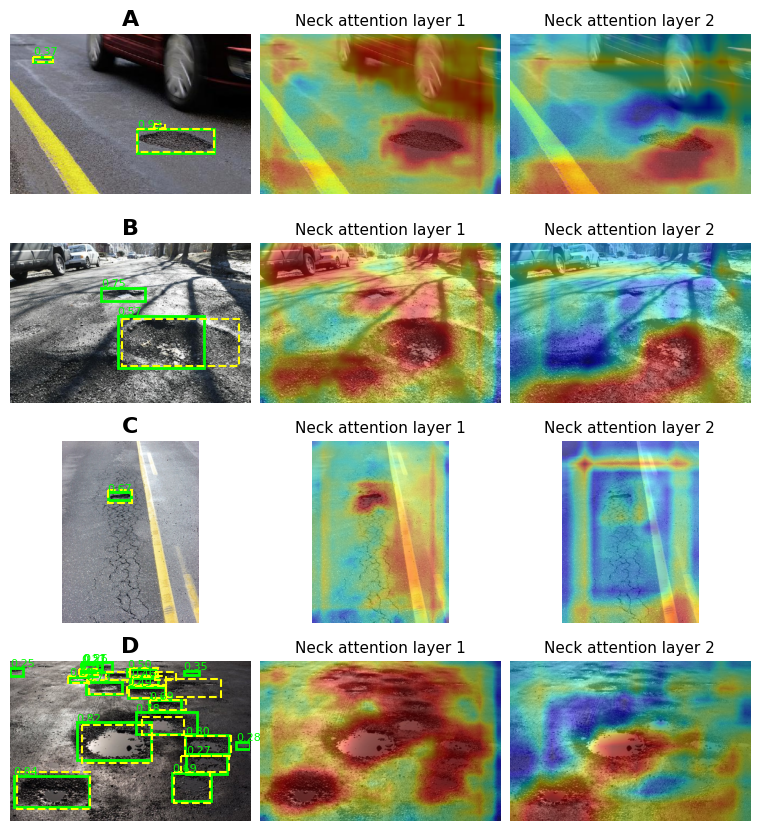

Attention maps saved: ./attention_results/cbam_spatial_attention_maps.png
Vector PDF saved: ./attention_results/cbam_spatial_attention_maps.pdf
Built at 7.4in x 8.09in -- place with \includegraphics[width=\linewidth]{cbam_spatial_attention_maps.pdf} in a figure* environment, with NO additional scale factor.
Row letter -> filename mapping: ['A = img-654.jpg', 'B = 606.jpg', 'C = 512.jpg', 'D = 348.jpg']
  Hooks removed
Visualisation model freed


In [19]:
# Reloads the best-seed checkpoint, hooks SpatialAttention.forward to capture the CBAM spatial gate maps, and renders the attention-map figure used in the paper.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json as _json
import string
from ultralytics import YOLO
import torch, cv2, numpy as np, gc, os


plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Reload best-seed model from saved checkpoint
best_seed = SEEDS[0]
if multi_seed_results:
    best_seed = max(
        multi_seed_results, key=lambda r: r["metrics_default"].get("mAP@0.5", 0)
    )["seed"]
print(f"Using seed={best_seed} model for visualisation")

ckpt_path = os.path.join(SAVE_DIR, f"YOLOv8m_ECA_CBAM_seed{best_seed}_complete.pt")
ckpt = torch.load(ckpt_path, map_location=DEVICE)

gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

vis_model = YOLO(ckpt["yolo_weights_path"])
vis_model.to(DEVICE)
vis_injector = AttentionHookInjector(
    vis_model.model, ECA_CBAM, ckpt["cbam_reduction"], ckpt["cbam_kernel"]
)
vis_injector.attention_modules.load_state_dict(ckpt["attention_state_dict"])
vis_injector.attach()
print(f"Model reloaded with attention weights restored")

# Sample images
import random

random.seed(42)
sample_recs = random.sample(
    [r for r in val_recs if r["gt_boxes"]], min(4, len(val_recs))
)

# Letter labels A, B, C, D -- one per row, replacing raw filenames as titles
ROW_LETTERS = list(string.ascii_uppercase[: len(sample_recs)])


FIG_WIDTH_IN = 7.4
FONT_ROW_LETTER = 16  # A / B / C / D row titles
FONT_COL_HEADER = 11  # "Neck attention layer N" column titles
FONT_SCORE = 8  # detection confidence score text
FONT_LEGEND = 9  # filename legend at the bottom

n_rows = len(sample_recs)
panel_w = FIG_WIDTH_IN / 3
panel_h = panel_w * 0.82
legend_h = 0.0
fig_h = n_rows * panel_h + legend_h

fig, axes = plt.subplots(n_rows, 3, figsize=(FIG_WIDTH_IN, fig_h))


legend_entries = []

for row_idx, rec in enumerate(sample_recs):
    img_bgr = cv2.imread(str(rec["image_path"]))
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = img_rgb.shape[:2]

    spatial_maps = {}
    cap_hooks = []
    for att_idx, att_mod in enumerate(vis_injector.attention_modules):
        if hasattr(att_mod, "sa"):

            def make_cap(i):
                def cap_hook(module, inp, out):
                    spatial_maps[i] = out.detach().cpu()

                return cap_hook

            cap_hooks.append(att_mod.sa.register_forward_hook(make_cap(att_idx)))

    result = vis_model.predict(img_bgr, conf=CONF_DEFAULT, verbose=False)
    for h in cap_hooks:
        h.remove()

    ax_row = axes[row_idx] if n_rows > 1 else axes
    letter = ROW_LETTERS[row_idx]
    legend_entries.append(f"{letter} = {rec['image_path'].name}")

    ax_row[0].imshow(img_rgb)
    if result and result[0].boxes is not None and len(result[0].boxes.xyxy) > 0:
        for box, score in zip(
            result[0].boxes.xyxy.cpu().numpy(), result[0].boxes.conf.cpu().numpy()
        ):
            x1, y1, x2, y2 = [int(v) for v in box]
            ax_row[0].add_patch(
                mpatches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1, lw=2, edgecolor="lime", facecolor="none"
                )
            )
            ax_row[0].text(
                x1, y1 - 4, f"{score:.2f}", color="lime", fontsize=FONT_SCORE
            )
    for gt in rec["gt_boxes"]:
        x1, y1, x2, y2 = [int(v) for v in gt]
        ax_row[0].add_patch(
            mpatches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                lw=1.5,
                edgecolor="yellow",
                facecolor="none",
                linestyle="--",
            )
        )
    ax_row[0].set_title(letter, fontsize=FONT_ROW_LETTER, fontweight="bold")
    ax_row[0].axis("off")

    for col_idx, map_key in enumerate(sorted(spatial_maps.keys())[-2:]):
        att_np = spatial_maps[map_key][0, 0].numpy()
        att_res = cv2.resize(att_np, (img_w, img_h), interpolation=cv2.INTER_LINEAR)
        att_norm = (att_res - att_res.min()) / (att_res.max() - att_res.min() + 1e-8)
        heatmap = (plt.cm.jet(att_norm)[:, :, :3] * 255).astype(np.uint8)
        overlay = cv2.addWeighted(img_rgb, 0.55, heatmap, 0.45, 0)
        ax_row[col_idx + 1].imshow(overlay)
        ax_row[col_idx + 1].set_title(
            f"Neck attention layer {map_key}", fontsize=FONT_COL_HEADER
        )
        ax_row[col_idx + 1].axis("off")

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0.15, wspace=0.04)


vis_path = os.path.join(OUTPUT_DIR, "cbam_spatial_attention_maps.png")
pdf_path = os.path.join(OUTPUT_DIR, "cbam_spatial_attention_maps.pdf")
plt.savefig(vis_path, dpi=300, bbox_inches="tight", pad_inches=0)
plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0)
plt.show()
print(f"Attention maps saved: {vis_path}")
print(f"Vector PDF saved: {pdf_path}")
print(
    f"Built at {FIG_WIDTH_IN}in x {fig_h:.2f}in -- place with "
    f"\\includegraphics[width=\\linewidth]{{cbam_spatial_attention_maps.pdf}} "
    f"in a figure* environment, with NO additional scale factor."
)
print("Row letter -> filename mapping:", legend_entries)

# Free visualisation model
vis_injector.detach()
del vis_model, vis_injector
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("Visualisation model freed")

Final Paper-Ready Summary

In [20]:
# Prints the final paper-ready summary, three-seed mean +/- std with deltas against ablation variant A and the full ablation table, and writes a master summary JSON.
import json as _json

# Reload from JSONs if needed (after kernel restart)
if not multi_seed_results:
    for seed in SEEDS:
        p = os.path.join(OUTPUT_DIR, f"YOLOv8m_ECA_CBAM_seed{seed}_result.json")
        if os.path.exists(p):
            with open(p) as f:
                multi_seed_results.append(_json.load(f))

keys = ["mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1"]
stats = {}
for k in keys:
    vals = [
        r["metrics_default"].get(k)
        for r in multi_seed_results
        if r["metrics_default"].get(k) is not None
    ]
    if vals:
        stats[k] = {
            "mean": float(np.mean(vals)),
            "std": float(np.std(vals, ddof=1) if len(vals) > 1 else 0.0),
        }

print("=" * 72)
print("  EXPERIMENT B v2 -- FINAL RESULTS")
print("  YOLOv8m + ECA+CBAM Hybrid Attention for Pothole Detection")
print("=" * 72)

# Deltas are measured against variant A (no attention) of the multi-seed
_ablation_A = {}
if "df_ablation_summary" in dir():
    _a = df_ablation_summary[df_ablation_summary["Variant"].str.startswith("A")]
    if len(_a):
        _ablation_A = {
            k: _a[f"{k}_mean"].values[0]
            for k in ("mAP@0.5", "Precision", "Recall", "F1")
            if f"{k}_mean" in _a.columns
        }

print("\n1. MULTI-SEED  (n=3, conf=0.25)")
for k, s in stats.items():
    bv = _ablation_A.get(k)
    d = f"  delta={s['mean'] - bv:+.4f}" if bv is not None else ""
    print(f"  {k:<18}: {s['mean']:.4f} +/- {s['std']:.4f}{d}")

print("\n2. ABLATION  (mean +/- std across 3 seeds, conf=0.25)")
if "df_ablation_summary" in dir():
    print(
        df_ablation_summary[
            ["Variant", "mAP@0.5_mean", "mAP@0.5_std", "F1_mean", "F1_std"]
        ].to_string(index=False)
    )
else:
    print("  Run the multi-seed ablation cell first.")


# Save master summary
summary_path = os.path.join(OUTPUT_DIR, "ExpB_v2_master_summary.json")
with open(summary_path, "w") as f:
    _json.dump(
        {
            "multi_seed_stats": stats,
            "multi_seed_runs": multi_seed_results,
            "ablation": (
                df_ablation_summary.to_dict(orient="records")
                if "df_ablation_summary" in dir()
                else []
            ),
            "ablation_baseline_A": _ablation_A,
        },
        f,
        indent=2,
    )
print(f"\nMaster summary: {summary_path}")


  EXPERIMENT B v2 -- FINAL RESULTS
  YOLOv8m + ECA+CBAM Hybrid Attention for Pothole Detection

1. MULTI-SEED  (n=3, conf=0.25)
  mAP@0.5           : 0.8141 +/- 0.0142  delta=+0.0081
  mAP@0.5:0.95      : 0.5423 +/- 0.0050
  Precision         : 0.7922 +/- 0.0201  delta=+0.0023
  Recall            : 0.7510 +/- 0.0238  delta=+0.0176
  F1                : 0.7708 +/- 0.0121  delta=+0.0106

2. ABLATION  (mean +/- std across 3 seeds, conf=0.25)
             Variant  mAP@0.5_mean  mAP@0.5_std  F1_mean   F1_std
   A -- No attention      0.805933     0.010736 0.760133 0.011123
       B -- ECA only      0.798633     0.007289 0.753333 0.006802
      C -- CBAM only      0.801200     0.003439 0.754433 0.007932
D -- ECA+CBAM (full)      0.814067     0.014199 0.770767 0.012106

Master summary: ./attention_results/ExpB_v2_master_summary.json


---
## Paper export

Bundles **this notebook's** figures, tables and raw metrics (everything under
its own `OUTPUT_DIR`) into one timestamped zip, with a
tidy `all_metrics.csv` to plot from, a booktabs `results_table.tex`, and a
`manifest.json` recording the environment, the split, and the exact metric
definitions behind the numbers. Also warns when a figure is older than the
newest metrics table -- i.e. was probably drawn from superseded numbers.


In [21]:
# +==============================================================+
# |  PAPER EXPORT -- bundle every result for the manuscript       |
# +==============================================================+
# Collects every figure, table and raw metric this project produced into
# ONE timestamped zip, alongside:
#   metrics/all_metrics.csv   tidy table -- plot straight from this
#   metrics/results_table.tex booktabs LaTeX, ready to \input{}
#   manifest.json             provenance: versions, split, seed, and the
#                             exact metric definitions the numbers use
#
# The manifest matters. This project's metrics were redefined (COCO-101 AP
# instead of VOC-11, corrected greedy matcher, throughput FPS instead of
# mean-of-reciprocals, baselines re-measured on the held-out split), so any
# artifact produced before that change is NOT comparable with one produced
# after. The staleness check below flags exactly that.
#
# SCOPE: this bundles THIS notebook's results only -- everything written to
# its own OUTPUT_DIR. Other notebooks in the project have their own output
# directories and their own export cell; run each one to get its own zip.

import os, re, json, zipfile, hashlib, platform, shutil, glob as _g
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd

BUNDLE_NAME = "YOLOv8_CBAM_ECA"  # this notebook
EXPORT_STEM = f"{BUNDLE_NAME}_results"

# Extra directories to include, if this notebook writes results outside
# OUTPUT_DIR. Model weights (.pt/.pth) are never collected -- only figures,
# tables and raw metrics, by extension.
EXTRA_RESULT_DIRS = []

# Runs whose results must never reach a paper table. 'smoke_' are the
# 1-epoch pipeline smoke tests (mAP ~0.35) -- real-looking numbers from a
# deliberately untrained model. Excluded by name and reported, never
# dropped silently.
EXCLUDE_RUN_PREFIXES = ("smoke_",)

# In-memory variables that hold OTHER notebooks' numbers, not this one's.
# BASELINES no longer exists -- deltas are now taken from ablation variant
# A, computed in this notebook -- but the name is kept in the filter so an
# older kernel state cannot leak external rows in. PREV_ATTENTION_RESULT is
# a superseded buggy run. Rows sourced
# from these are dropped -- this bundle contains only what THIS notebook
# measured. Set INCLUDE_EXTERNAL = True if you want them back for a
# combined table.
EXTERNAL_RESULT_VARS = {"BASELINES", "existing_results", "PREV_ATTENTION_RESULT"}
INCLUDE_EXTERNAL = False

FIG_EXT = {".png", ".pdf", ".svg", ".eps"}
TABLE_EXT = {".csv"}
RAW_EXT = {".json", ".txt", ".yaml", ".yml"}


# -- 1. This notebook's result directories only ------------------------
result_dirs, seen = [], set()
for d in [OUTPUT_DIR] + list(EXTRA_RESULT_DIRS):
    rp = os.path.realpath(d)
    if os.path.isdir(rp) and rp not in seen:
        seen.add(rp)
        result_dirs.append(rp)

print(f"Bundling results for: {BUNDLE_NAME}")
for d in result_dirs:
    n = sum(1 for _ in Path(d).rglob("*") if _.is_file())
    print(f"   {d}  ({n} files)")
if not result_dirs:
    print(
        f"   OUTPUT_DIR does not exist ({OUTPUT_DIR}) -- "
        f"run this notebook's evaluation cells first"
    )


# -- 2. Harvest metrics from memory + from every CSV on disk -----------
METRIC_KEYS = {"mAP@0.5", "F1"}

# A bare result variable carries no model name, so map the known ones to their
# real names. Anything unmapped is reported, not guessed at -- a variable name
# like 'cbam_result' must never end up as a row label in a paper table.
VAR_NAME_MAP = {
    "cbam_result": "YOLOv8m+CBAM",
    "ca_result": "YOLOv8m+CoordAttn",
    "ensemble_result": "YOLO+FRCNN Ensemble",
    "yolo_base_result": "YOLOv8m (base)",
    "frcnn_base_result": "Faster R-CNN (base)",
    "rcnn_result": "Faster R-CNN",
    "ssd_result": "SSD-VGG16",
    "rtdetr_result": "RT-DETR",
    "swin_result": "RT-DETR (Swin)",
}


def harvest_in_memory():
    rows, skipped = [], []
    for name, val in list(globals().items()):
        if name.startswith("_") or not isinstance(val, dict) or not val:
            continue
        if name in EXTERNAL_RESULT_VARS and not INCLUDE_EXTERNAL:
            continue
        if METRIC_KEYS <= set(val):  # a single result dict
            if name in VAR_NAME_MAP:
                rows.append(
                    {
                        "Model": VAR_NAME_MAP[name],
                        "origin": "this-notebook",
                        "source": "in-memory",
                        **{k: v for k, v in val.items() if not k.startswith("_")},
                    }
                )
            else:
                skipped.append(name)
        elif all(isinstance(v, dict) for v in val.values()):  # dict keyed by model
            for k, v in val.items():
                if METRIC_KEYS <= set(v):
                    rows.append(
                        {
                            "Model": k,
                            "origin": "external"
                            if name in EXTERNAL_RESULT_VARS
                            else "this-notebook",
                            "source": "in-memory",
                            **{
                                kk: vv for kk, vv in v.items() if not kk.startswith("_")
                            },
                        }
                    )
    if skipped:
        print(
            f"   note: unmapped in-memory result variable(s) {skipped} -- "
            f"add them to VAR_NAME_MAP to include them"
        )
    return rows


def harvest_result_jsons(dirs):
    """Harvest per-run JSON results written by the training loop.

    FIX: the previous version only inspected dict-valued globals, so
    notebooks that keep results in a LIST (multi_seed_results,
    ablation_results) with metrics nested under 'metrics_default' /
    'metrics_best' contributed NOTHING to all_metrics.csv -- the attention
    notebooks exported a results table containing only their baselines and
    none of their own runs. Reading the *_result.json files straight off
    disk is also restart-proof: it works even if the kernel was restarted
    and the in-memory results are gone.
    """
    rows = []
    for d in dirs:
        for jf in sorted(Path(d).rglob("*.json")):
            try:
                blob = json.load(open(jf))
            except Exception:
                continue
            for rec in blob if isinstance(blob, list) else [blob]:
                if not isinstance(rec, dict):
                    continue
                md = rec.get("metrics_default")
                mb = rec.get("metrics_best") or {}
                if isinstance(md, dict) and METRIC_KEYS <= set(md):
                    name = (
                        rec.get("run_name")
                        or rec.get("model")
                        or jf.stem.replace("_result", "")
                    )
                    row = {
                        "Model": name,
                        "origin": "this-notebook",
                        "source": os.path.relpath(jf),
                    }
                    row.update({k: v for k, v in md.items() if k != "conf"})
                    if isinstance(mb, dict) and mb:
                        row["best_conf"] = rec.get("best_conf", mb.get("conf"))
                        for src_k, dst_k in [
                            ("Precision", "P@best"),
                            ("Recall", "R@best"),
                            ("F1", "F1@best"),
                        ]:
                            if src_k in mb:
                                row[dst_k] = mb[src_k]
                    for extra in ("seed", "attention"):
                        if extra in rec:
                            row[extra] = rec[extra]
                    rows.append(row)
                elif METRIC_KEYS <= set(rec):
                    rows.append(
                        {
                            "Model": rec.get("run_name") or jf.stem,
                            "origin": "this-notebook",
                            "source": os.path.relpath(jf),
                            **{
                                k: v
                                for k, v in rec.items()
                                if not isinstance(v, (dict, list))
                            },
                        }
                    )
    return rows


def harvest_csvs(dirs):
    rows = []
    for d in dirs:
        for csv in Path(d).rglob("*.csv"):
            try:
                sub = pd.read_csv(csv)
            except Exception:
                continue
            if "Model" not in sub.columns or not (METRIC_KEYS & set(sub.columns)):
                continue
            for _, r in sub.iterrows():
                rows.append(
                    {
                        "origin": "this-notebook",
                        "source": os.path.relpath(csv),
                        **r.to_dict(),
                    }
                )
    return rows


rows = (
    harvest_result_jsons(result_dirs) + harvest_in_memory() + harvest_csvs(result_dirs)
)

_excluded = [
    r["Model"] for r in rows if str(r.get("Model", "")).startswith(EXCLUDE_RUN_PREFIXES)
]
rows = [r for r in rows if not str(r.get("Model", "")).startswith(EXCLUDE_RUN_PREFIXES)]
if _excluded:
    print(
        f"   excluded {len(_excluded)} non-final run(s) from the metrics table: "
        f"{sorted(set(_excluded))}"
    )

# Scope guard: keep only what THIS notebook measured.
if not INCLUDE_EXTERNAL:
    _ext = sorted({r["Model"] for r in rows if r.get("origin") != "this-notebook"})
    rows = [r for r in rows if r.get("origin") == "this-notebook"]
    if _ext:
        print(
            f"   excluded {len(_ext)} external/baseline row(s) -- this bundle is "
            f"scoped to {BUNDLE_NAME} only: {_ext}"
        )
if rows:
    metrics_df = pd.DataFrame(rows)
    # in-memory wins over a possibly-stale CSV for the same model
    metrics_df["_rank"] = (metrics_df["source"] != "in-memory").astype(int)
    metrics_df = (
        metrics_df.sort_values("_rank")
        .drop_duplicates(subset=["Model"], keep="first")
        .drop(columns="_rank")
    )
    front = [
        c
        for c in [
            "Model",
            "mAP@0.5",
            "mAP@0.5:0.95",
            "Precision",
            "Recall",
            "F1",
            "best_conf",
            "P@best",
            "R@best",
            "F1@best",
            "FPS",
            "TP",
            "FP",
            "FN",
            "attention",
            "seed",
            "source",
        ]
        if c in metrics_df.columns
    ]
    metrics_df = metrics_df[
        front + [c for c in metrics_df.columns if c not in front and c != "origin"]
    ]
    # sort on F1@best, falling back to F1 per-row so models evaluated without
    # a confidence sweep are ranked on their own F1 instead of sorting as NaN
    _key = metrics_df["F1"] if "F1" in metrics_df.columns else 0.0
    if "F1@best" in metrics_df.columns:
        _key = metrics_df["F1@best"].fillna(_key)
    metrics_df = (
        metrics_df.assign(_key=_key)
        .sort_values("_key", ascending=False)
        .drop(columns="_key")
        .reset_index(drop=True)
    )
    print(f"\nCollected {len(metrics_df)} model rows -- all from {BUNDLE_NAME}")
    if len(metrics_df) == 0:
        print(
            "   WARNING: none of this notebook's own runs were collected -- "
            "check that its result JSON/CSV files are in OUTPUT_DIR"
        )
else:
    metrics_df = pd.DataFrame()
    print("\nNo metric rows found -- run the evaluation cells first")


# -- 3. Stage the bundle -----------------------------------------------
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
stage = os.path.join(ROOT, f"{EXPORT_STEM}_{stamp}")
zip_path = stage + ".zip"
for sub in ("figures", "metrics", "raw"):
    os.makedirs(os.path.join(stage, sub), exist_ok=True)

inventory, name_counts = [], {}


def stage_file(src, sub):
    """Copy into the bundle, prefixing on collision so nothing is silently lost."""
    base = os.path.basename(src)
    parent = os.path.basename(os.path.dirname(src))
    key = (sub, base)
    name_counts[key] = name_counts.get(key, 0) + 1
    dst_name = base if name_counts[key] == 1 else f"{parent}__{base}"
    dst = os.path.join(stage, sub, dst_name)
    if os.path.exists(dst):
        dst = os.path.join(stage, sub, f"{parent}__{base}")
    shutil.copy2(src, dst)
    h = hashlib.sha256(open(src, "rb").read()).hexdigest()[:16]
    inventory.append(
        {
            "bundle_path": os.path.relpath(dst, stage),
            "source": os.path.relpath(src),
            "bytes": os.path.getsize(src),
            "modified": datetime.fromtimestamp(os.path.getmtime(src)).isoformat(
                timespec="seconds"
            ),
            "sha256_16": h,
        }
    )


for d in result_dirs:
    for f in sorted(Path(d).rglob("*")):
        if not f.is_file():
            continue
        ext = f.suffix.lower()
        sub = (
            "figures"
            if ext in FIG_EXT
            else "metrics"
            if ext in TABLE_EXT
            else "raw"
            if ext in RAW_EXT
            else None
        )
        if sub:
            stage_file(str(f), sub)

# consolidated tables
if not metrics_df.empty:
    metrics_df.to_csv(os.path.join(stage, "metrics", "all_metrics.csv"), index=False)
    metrics_df.to_json(
        os.path.join(stage, "metrics", "all_metrics.json"), orient="records", indent=2
    )
    tex_cols = [
        c
        for c in ["Model", "mAP@0.5", "Precision", "Recall", "F1", "FPS"]
        if c in metrics_df.columns
    ]
    try:
        # Format to strings first: pandas' float_format would print FPS as
        # 120.0000 and missing values as a literal "NaN" in the .tex.
        def _tex_escape(v):
            return (
                str(v)
                .replace("\\", r"\textbackslash{}")
                .replace("_", r"\_")
                .replace("&", r"\&")
                .replace("%", r"\%")
                .replace("#", r"\#")
            )

        tex_df = metrics_df[tex_cols].copy()
        for c in tex_cols:
            if c == "Model":
                tex_df[c] = tex_df[c].map(_tex_escape)
            else:
                dp = 1 if c == "FPS" else 4
                tex_df[c] = tex_df[c].map(
                    lambda v, dp=dp: "--" if pd.isna(v) else f"{float(v):.{dp}f}"
                )
        tex = tex_df.to_latex(
            index=False,
            escape=False,
            column_format="l" + "r" * (len(tex_cols) - 1),
            caption=(
                "Pothole detection results on the held-out validation split. "
                "mAP@0.5 is COCO 101-point interpolated; FPS is throughput "
                "(images/total time) with warm-up discarded. "
                "-- indicates the metric was not measured for that model."
            ),
            label="tab:pothole_results",
        )
        open(os.path.join(stage, "metrics", "results_table.tex"), "w").write(tex)
    except Exception as e:
        print(f"   (LaTeX table skipped: {e})")


# -- 4. Provenance manifest --------------------------------------------
def _ver(mod):
    try:
        return __import__(mod).__version__
    except Exception:
        return None


def _n_gt(recs):
    try:
        return int(sum(len(r["gt_boxes"]) for r in recs))
    except Exception:
        return None


manifest = {
    "notebook": BUNDLE_NAME,
    "created": datetime.now().isoformat(timespec="seconds"),
    "notebook_root": os.path.realpath(ROOT),
    "result_dirs": result_dirs,
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": _ver("numpy"),
        "pandas": _ver("pandas"),
        "torch": _ver("torch"),
        "ultralytics": _ver("ultralytics"),
        "opencv": _ver("cv2"),
        "torchvision": _ver("torchvision"),
        "device": globals().get("DEVICE"),
        "gpu": (
            torch.cuda.get_device_name(0) if globals().get("DEVICE") == "cuda" else None
        ),
    },
    "dataset": {
        "sources": [
            "chitholian/annotated-potholes-dataset",
            "andrewmvd/pothole-detection",
            "ashishkumarak/training-setzip",
        ],
        "dedup": "normalized 64x64 grayscale nearest-neighbour, mean-abs threshold 1.0",
        "n_images_after_dedup": len(globals().get("records", []) or []) or None,
        "n_train": len(globals().get("train_recs", []) or []) or None,
        "n_val": len(globals().get("val_recs", []) or []) or None,
        "n_val_gt_boxes": _n_gt(globals().get("val_recs", []) or []),
        "split_seed": 42,
        "split": "80/20 shuffled after dedup",
    },
    "metric_definitions": {
        "mAP@0.5": "COCO 101-point interpolated AP at IoU 0.5 "
        "(matches ultralytics.utils.metrics.compute_ap)",
        "mAP@0.5(VOC11)": "legacy PASCAL VOC-2007 11-point AP -- reported for "
        "continuity only, NOT comparable with model.val()",
        "matching": "greedy by descending confidence; each detection matched to "
        "the highest-IoU ground truth that is still unmatched",
        "iou_threshold": 0.5,
        "conf_fixed": globals().get("CONF_THRESH", globals().get("CONF_DEFAULT")),
        "conf_sweep": globals().get("CONF_SWEEP"),
        "F1": "at the fixed confidence threshold",
        "F1@best": "at the confidence maximising F1 (sweep) -- use this when "
        "comparing against Ultralytics model.val() numbers",
        "FPS": "throughput = images / total wall-clock, first 5 iterations "
        "discarded as warm-up, CUDA-synchronised",
    },
    "files": inventory,
}
json.dump(manifest, open(os.path.join(stage, "manifest.json"), "w"), indent=2)


# -- 5. Staleness check ------------------------------------------------
# Any figure older than the newest metrics table was almost certainly drawn
# from superseded numbers.
warnings_out = []
csv_times = [
    f["modified"] for f in inventory if f["bundle_path"].startswith("metrics/")
]
if csv_times:
    newest = max(csv_times)
    stale = [
        f
        for f in inventory
        if f["bundle_path"].startswith("figures/") and f["modified"] < newest
    ]
    if stale:
        warnings_out.append(
            f"{len(stale)} figure(s) predate the newest metrics table ({newest}) -- "
            "they may have been rendered from superseded numbers:"
        )
        for f in stale[:10]:
            warnings_out.append(f"    {f['bundle_path']}  ({f['modified']})")
        if len(stale) > 10:
            warnings_out.append(f"    ... and {len(stale) - 10} more")


# -- 6. README + zip ---------------------------------------------------
readme = f"""POTHOLE DETECTION -- PAPER BUNDLE
Notebook: {BUNDLE_NAME}
Created:  {manifest["created"]}

Scope: results from THIS notebook only ({OUTPUT_DIR}). Each notebook in the
project has its own export cell and produces its own bundle.

  metrics/all_metrics.csv    every model x every metric, tidy -- plot from this
  metrics/all_metrics.json   same, JSON
  metrics/results_table.tex  booktabs LaTeX, \\input{{}} directly
  metrics/*.csv              per-notebook result tables as generated
  figures/                   all .png/.pdf figures produced by the notebooks
  raw/                       per-run JSON, configs, logs
  manifest.json              versions, split, seed, exact metric definitions
                             + sha256 of every file

METRICS -- read before quoting any number
  mAP@0.5 is COCO 101-point interpolated (same as Ultralytics model.val()).
  Any 'mAP@0.5(VOC11)' column is the legacy VOC-2007 11-point figure and must
  NOT be tabled next to a COCO number.
  F1 is at a fixed confidence threshold; F1@best is at the F1-maximising
  threshold. Ultralytics' model.val() reports the latter, so use F1@best for
  cross-comparison and say which one the paper quotes.
  FPS is throughput (images / total time), warm-up discarded, CUDA-synced.

All numbers are on the held-out validation split
({manifest["dataset"]["n_val"]} images, {manifest["dataset"]["n_val_gt_boxes"]} GT boxes, seed 42).
"""
open(os.path.join(stage, "README.txt"), "w").write(readme)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(Path(stage).rglob("*")):
        if f.is_file():
            zf.write(f, f.relative_to(os.path.dirname(stage)))

n_fig = sum(1 for f in inventory if f["bundle_path"].startswith("figures/"))
n_tab = sum(1 for f in inventory if f["bundle_path"].startswith("metrics/"))
n_raw = sum(1 for f in inventory if f["bundle_path"].startswith("raw/"))

print("\n" + "=" * 62)
print(f"  BUNDLE -> {zip_path}")
print(
    f"  {os.path.getsize(zip_path) / 1e6:.2f} MB   "
    f"{n_fig} figures, {n_tab} tables, {n_raw} raw, {len(metrics_df)} model rows"
)
print(f"  staged (unzipped) at {stage}")
print("=" * 62)
if not metrics_df.empty:
    show = [
        c
        for c in ["Model", "mAP@0.5", "F1", "F1@best", "FPS"]
        if c in metrics_df.columns
    ]
    print(metrics_df[show].to_string(index=False))
if warnings_out:
    print("\nWARNINGS")
    for w in warnings_out:
        print("  " + w)
else:
    print("\nNo staleness warnings.")


Bundling results for: YOLOv8_CBAM_ECA
   /home/vr3/Pothole_Detection/Updated Code 926/Yolov8 Final/attention_results  (21 files)
   note: unmapped in-memory result variable(s) ['m', 'm_def', 'm_best', 'stats'] -- add them to VAR_NAME_MAP to include them
   excluded 2 non-final run(s) from the metrics table: ['smoke_Baseline', 'smoke_CBAM_Only']

Collected 15 model rows -- all from YOLOv8_CBAM_ECA

  BUNDLE -> ./YOLOv8_CBAM_ECA_results_20260828_040505.zip
  7.91 MB   2 figures, 0 tables, 19 raw, 15 model rows
  staged (unzipped) at ./YOLOv8_CBAM_ECA_results_20260828_040505
                             Model  mAP@0.5     F1  F1@best   FPS
          YOLOv8m_ECA_CBAM_seed123   0.8272 0.7842   0.7842 138.6
 ablation_YOLOv8m_ECA_CBAM_seed123   0.8272 0.7842   0.7842   NaN
           YOLOv8m_ECA_CBAM_seed42   0.8160 0.7674   0.7684 140.7
  ablation_YOLOv8m_ECA_CBAM_seed42   0.8160 0.7674   0.7684   NaN
  ablation_YOLOv8m_Baseline_seed42   0.8098 0.7670   0.7670   NaN
 ablation_YOLOv8m_Baselin